# 07. Large Dataset Handling

## 📚 Learning Objectives

By completing this notebook, you will:
- Load and process large datasets (chunking, etc.)
- Use distributed or out-of-core tools where relevant
- Summarize and visualize at scale

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2, lesson 01 (chunking) and Unit 5, lessons 02-03 — the practical decision procedure for data that will not fit in RAM.

**Used later in:** Course 12 (AIAT 126) — Unit 3, whose project data may well be this size.

---


## 🎯 The case: one billion rows, and two orders of magnitude

On **1 January 2024** Gunnar Morling posted the **One Billion Row Challenge**: read a text
file of **1,000,000,000** temperature measurements and compute the min, mean and max per
weather station. Nothing conceptually difficult — a `groupby` — at a size that makes every
lazy decision expensive.

It went viral. Hundreds of people competed, first in Java and then in Go, Rust, C, C#,
Fortran, Erlang and inside databases. By the end of January the leading solutions finished
in **under 1.7 seconds**, having improved on the naive baseline by roughly **two orders of
magnitude**. Nobody bought a cluster. The gains came from not materialising what you do not
need, touching each byte once, and keeping memory bounded.

That is precisely this lesson's subject, and the alternative is well documented. In autumn
2020 Public Health England collated COVID-19 test results in legacy `.xls` files, which stop
at **65,536 rows**. Between 25 September and 2 October, **15,841 positive cases** silently
overflowed and never reached contact tracing.

**What goes wrong without these techniques.** `pd.read_csv` on a file larger than RAM does
not run slowly — it fails, or the machine starts swapping and everything stops. You are
about to stream a real **708 MB, 2,300,825-row** capture in 12 chunks, aggregate all of it,
and never hold more than **19.1 MB** at once against the **219.5 MB** the whole frame would
need.


## The Story

**BEFORE**: You can work with small datasets but don't know strategies for handling datasets that don't fit in memory.

**AFTER**: You'll learn strategies for large datasets: chunking, streaming, memory-efficient processing, and out-of-core computing!

**Why this matters**: Large Dataset Handling is essential for building complete, professional data science solutions!

---

# Unit 5 - Example 07: Large Dataset Handling

## 🔗 Solving the Problem from Example 06

**Remember the dead end from Example 06?**
- We learned performance optimization techniques
- But even optimized, very large datasets require special handling
- We needed strategies for handling massive datasets

**This notebook solves that problem!**
- We'll learn **large dataset handling strategies**
- We'll learn **chunking, streaming, and memory-efficient processing**
- We'll learn **techniques for datasets that don't fit in memory**

**This solves the large dataset problem from Example 06!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `cicids2017.csv` — a 708 MB packet-capture summary from the
  Canadian Institute for Cybersecurity: **2,300,825 real network flows** recorded
  over five days, each with 79 statistics and an attack label. No file is
  generated here; we stream a genuinely large one straight off disk.
- pandas (chunked reading), matplotlib

**Outputs:** What you'll see when you run the cells

- The whole 2.3-million-row file aggregated without ever holding it in memory
- Measured memory: whole-file DataFrame vs one chunk

---


In [1]:
# WHAT: Import the data stack and timing tools.
# WHY: This lesson is about processing data that would not fit comfortably in memory.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Print the banner.
# WHY: Goal framing: read, aggregate, and summarize a million-row file without loading it whole.

print("=" * 70)
print("=" * 70)
print("\n📚 Prerequisites: Examples 02-06 completed, memory management knowledge")
print("🔗 This is Example 07 in Unit 5 - large dataset handling")
print("🎯 Goal: Master processing large datasets efficiently")
print("Reference: Study 18.pdf before running this code example.\n")


📚 Prerequisites: Examples 02-06 completed, memory management knowledge
🔗 This is Example 07 in Unit 5 - large dataset handling
🎯 Goal: Master processing large datasets efficiently
Reference: Study 18.pdf before running this code example.



## 1. A Genuinely Large File

In [3]:
# WHAT: Point at a real 708 MB capture file and measure how many rows it holds by streaming it.
# WHY: You cannot chunk-process a file you have not sized up. Counting rows without
#      loading the file is itself the first chunking exercise.

print("\n1. A Genuinely Large Real File")
print("-" * 70)

import os

DATA_DIR = '../../../Course 04/datasets/raw/'
large_file = DATA_DIR + 'cicids2017.csv'

file_mb = os.path.getsize(large_file) / 1e6
print(f"File: cicids2017.csv")
print(f"Size on disk: {file_mb:,.0f} MB")

# The columns we care about. usecols is the cheapest optimisation there is:
# the parser skips the other 73 columns entirely.
USECOLS = [' Destination Port', ' Flow Duration', ' Total Fwd Packets',
           ' Total Backward Packets', ' Fwd Packet Length Mean', ' Label']
chunk_size = 200_000

# Count the rows by streaming - at no point is the whole file in memory.
start = time.time()
total_rows = 0
for chunk_df in pd.read_csv(large_file, usecols=USECOLS, chunksize=chunk_size):
    total_rows += len(chunk_df)
count_time = time.time() - start
n_chunks = -(-total_rows // chunk_size)   # ceiling division

print(f"\n✓ Streamed the whole file in {count_time:.2f}s without loading it")
print(f"✓ Rows: {total_rows:,} network flows, read in {n_chunks} chunks of {chunk_size:,}")

# Peek at the first rows so we know what we are aggregating.
verify_df = pd.read_csv(large_file, usecols=USECOLS, nrows=5)
verify_df.columns = [c.strip() for c in verify_df.columns]
print(f"✓ Columns kept: {list(verify_df.columns)}")
print(f"✓ Sample data:\n{verify_df.head().to_string()}")
print("\n💡 This file is real network telemetry, not something we generated. A")
print("   production sensor writes one of these every day - which is exactly why")
print("   'just load it into pandas' stops being an option.")


1. A Genuinely Large Real File
----------------------------------------------------------------------
File: cicids2017.csv
Size on disk: 708 MB



✓ Streamed the whole file in 1.57s without loading it
✓ Rows: 2,300,825 network flows, read in 12 chunks of 200,000
✓ Columns kept: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packet Length Mean', 'Label']
✓ Sample data:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Fwd Packet Length Mean   Label
0                88            640                  7                       4               62.857143  BENIGN
1                88            900                  9                       4               66.666667  BENIGN
2                88           1205                  7                       4              396.571429  BENIGN
3                88            511                  7                       4               64.571429  BENIGN
4                88            773                  9                       4               68.000000  BENIGN

💡 This file is real network telemetry, not something we generated. A
  

2. PROCESSING IN CHUNKS


In [4]:
# WHAT: Read the real capture in 200k-row chunks, aggregating each as it streams past.
# WHY: Chunked reading bounds memory: at any moment only one chunk lives in RAM.

print("\n\n2. Processing in Chunks")
print("-" * 70)

results = []
chunk_processing_times = []
# Also record what each chunk COSTS in RAM and how many rows it holds, so the
# figure below can plot the memory profile without re-reading the file.
chunk_mem_profile = []
chunk_row_counts = []

start_total = time.time()
chunk_reader = pd.read_csv(large_file, usecols=USECOLS, chunksize=chunk_size)
for i, chunk_df in enumerate(chunk_reader, 1):
    chunk_start = time.time()

    # The CICIDS header has leading spaces in most column names - a real quirk
    # of this file. Strip them once per chunk rather than trusting the header.
    chunk_df.columns = chunk_df.columns.str.strip()

    # Per-chunk aggregation: mean flow duration per traffic label
    chunk_result = chunk_df.groupby('Label')['Flow Duration'].agg(['sum', 'count'])
    results.append(chunk_result)
    chunk_mem_profile.append(chunk_df.memory_usage(deep=True).sum() / 1e6)
    chunk_row_counts.append(len(chunk_df))
    chunk_processing_times.append(time.time() - chunk_start)

    if i % 4 == 0:
        print(f"Processed chunk {i}/{n_chunks}, time: {chunk_processing_times[-1]:.4f}s")

total_time = time.time() - start_total

# Combine: sum the per-chunk sums and counts, THEN divide. Averaging the
# per-chunk means would be wrong whenever the chunks hold different row counts.
combined = pd.concat(results).groupby(level=0).sum()
final_result = (combined['sum'] / combined['count']).sort_values(ascending=False)

print(f"\n✓ Processed {len(results)} chunks in {total_time:.2f} seconds")
print(f"✓ Average chunk processing time: {np.mean(chunk_processing_times):.4f} seconds")
print(f"\nMean flow duration (microseconds) per traffic type, "
      f"across all {int(combined['count'].sum()):,} flows:")
print(final_result.round(0).to_string())
print("\n⚠️  Note the aggregation trick: we carried SUM and COUNT per chunk, not the")
print("   mean. Averaging chunk means only works when every chunk is the same size -")
print("   the last chunk here holds "
      f"{int(total_rows - (n_chunks - 1) * chunk_size):,} rows, not {chunk_size:,}.")



2. Processing in Chunks
----------------------------------------------------------------------


Processed chunk 4/12, time: 0.0154s


Processed chunk 8/12, time: 0.0150s


Processed chunk 12/12, time: 0.0082s

✓ Processed 12 chunks in 1.90 seconds
✓ Average chunk processing time: 0.0146 seconds

Mean flow duration (microseconds) per traffic type, across all 2,300,825 flows:
Label
Heartbleed                    110679708.0
Infiltration                   78407720.0
DoS Slowhttptest               57719892.0
DoS Hulk                       57081732.0
DoS slowloris                  56554365.0
DoS GoldenEye                  23127222.0
DDoS                           16955592.0
BENIGN                         11473608.0
Web Attack � XSS                6715357.0
Web Attack � Brute Force        6506182.0
SSH-Patator                     6168967.0
FTP-Patator                     4513245.0
Web Attack � Sql Injection      2870398.0
Bot                              350943.0
PortScan                          82820.0

⚠️  Note the aggregation trick: we carried SUM and COUNT per chunk, not the
   mean. Averaging chunk means only works when every chunk is the same size -
   t

3. MEMORY-EFFICIENT PROCESSING


In [5]:
# WHAT: Compute a global mean with a running sum and count over chunks.
# WHY: Many statistics decompose into per-chunk pieces - the essence of out-of-core and distributed computing.

print("\n\n3. Memory Efficient Processing")
print("-" * 70)
# Use iterator to process without loading all into memory
total_sum = 0
total_count = 0
print("Processing with iterator (memory-efficient)...")
start_time = time.time()

chunk_reader = pd.read_csv(large_file, usecols=[' Total Fwd Packets'], chunksize=chunk_size)
chunk_num = 0
for chunk_df in chunk_reader:
    chunk_num += 1
    chunk_df.columns = chunk_df.columns.str.strip()
    total_sum += chunk_df['Total Fwd Packets'].sum()
    total_count += len(chunk_df)

avg_packets = total_sum / total_count
iterator_time = time.time() - start_time
print(f"Average forward packets per flow (computed incrementally): {avg_packets:.2f}")
print(f"Total forward packets across the whole capture: {total_sum:,}")
print(f"Processing time: {iterator_time:.2f} seconds")
print(f"Memory used: minimal - one {chunk_size:,}-row chunk at a time")
print(f"Processed {chunk_num} chunks covering {total_count:,} flows")



3. Memory Efficient Processing
----------------------------------------------------------------------
Processing with iterator (memory-efficient)...


Average forward packets per flow (computed incrementally): 9.12
Total forward packets across the whole capture: 20,993,023
Processing time: 1.34 seconds
Memory used: minimal - one 200,000-row chunk at a time
Processed 12 chunks covering 2,300,825 flows


4. VISUALIZATION




4. Creating Visualization
----------------------------------------------------------------------


Measured DataFrame memory - load all 2,300,825 rows at once: 219.5 MB
Measured DataFrame memory - one 200,000-row chunk in RAM: 19.1 MB
→ Chunking keeps ~12x less data in memory at any moment
   (and that is with only 6 of the file's 79 columns selected)


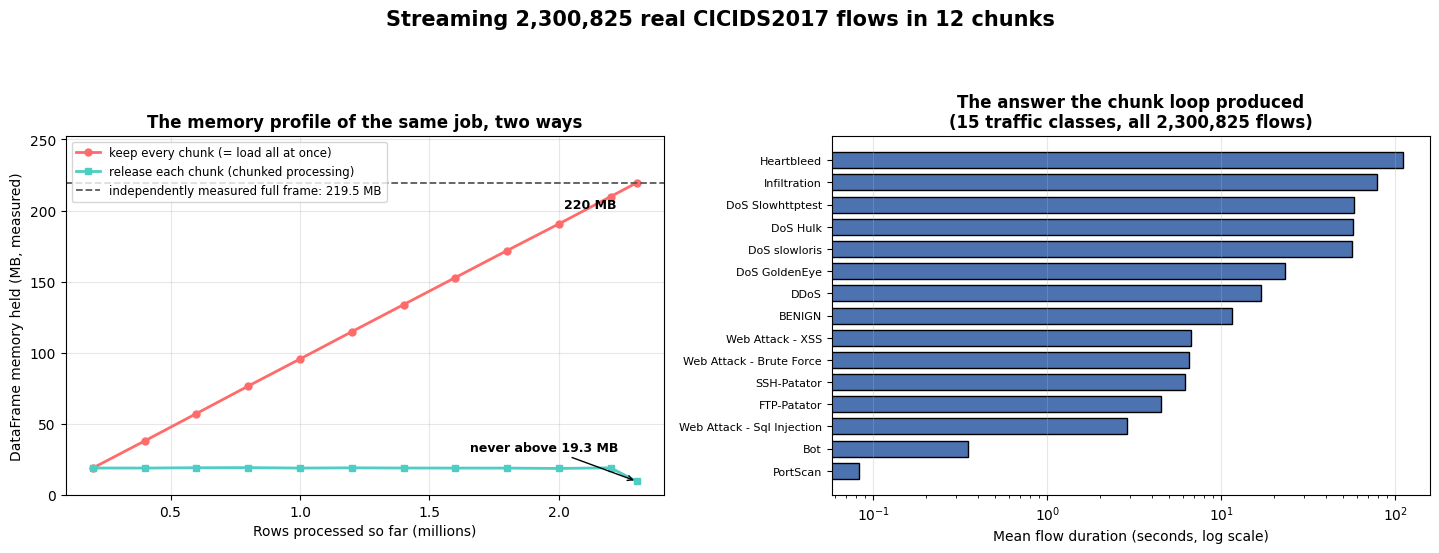

Peak memory: 219.5 MB if nothing is released, 19.3 MB if each chunk is - a 11x difference.
✓ Visualization created from measured values


In [6]:
# WHAT: Measure whole-file vs one-chunk memory and chart the per-chunk processing times.
# WHY: The measured ratio shows exactly how much RAM chunking saves - no invented numbers.

print("\n\n4. Creating Visualization")
print("-" * 70)

# MEASURE the memory difference instead of inventing numbers:
# full-file DataFrame vs a single chunk (what chunking keeps in RAM at once).
# NOTE: this is only for the six columns we selected. Loading all 79 columns of
# this file would need several gigabytes - which is the whole point.
df_full = pd.read_csv(large_file, usecols=USECOLS)
full_mem_mb = df_full.memory_usage(deep=True).sum() / 1e6
del df_full
one_chunk = next(pd.read_csv(large_file, usecols=USECOLS, chunksize=chunk_size))
chunk_mem_mb = one_chunk.memory_usage(deep=True).sum() / 1e6
del one_chunk
print(f"Measured DataFrame memory - load all {total_rows:,} rows at once: {full_mem_mb:.1f} MB")
print(f"Measured DataFrame memory - one {chunk_size:,}-row chunk in RAM: {chunk_mem_mb:.1f} MB")
print(f"→ Chunking keeps ~{full_mem_mb / chunk_mem_mb:.0f}x less data in memory at any moment")
print(f"   (and that is with only {len(USECOLS)} of the file's 79 columns selected)")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6))
fig.suptitle(f'Streaming {total_rows:,} real CICIDS2017 flows in {len(chunk_mem_profile)} chunks',
             fontsize=15, weight='bold')

# --- LEFT: what memory does as the file streams past, under the two strategies ---
cum_rows = np.cumsum(chunk_row_counts) / 1e6                 # millions of rows processed
keep_everything = np.cumsum(chunk_mem_profile)              # if no chunk is ever released
axes[0].plot(cum_rows, keep_everything, 'o-', color='#FF6B6B', lw=2, ms=5,
             label='keep every chunk (= load all at once)')
axes[0].plot(cum_rows, chunk_mem_profile, 's-', color='#4ECDC4', lw=2, ms=5,
             label='release each chunk (chunked processing)')
axes[0].axhline(full_mem_mb, ls='--', color='0.35', lw=1.3,
                label=f'independently measured full frame: {full_mem_mb:.1f} MB')
axes[0].annotate(f"{keep_everything[-1]:.0f} MB", xy=(cum_rows[-1], keep_everything[-1]),
                 xytext=(-52, -18), textcoords='offset points', fontsize=9, weight='bold')
axes[0].annotate(f"never above {max(chunk_mem_profile):.1f} MB",
                 xy=(cum_rows[-1], chunk_mem_profile[-1]), xytext=(-120, 22),
                 textcoords='offset points', fontsize=9, weight='bold',
                 arrowprops=dict(arrowstyle='->', lw=1))
axes[0].set_xlabel('Rows processed so far (millions)')
axes[0].set_ylabel('DataFrame memory held (MB, measured)')
axes[0].set_ylim(0, keep_everything[-1] * 1.15)
axes[0].set_title('The memory profile of the same job, two ways', fontsize=12, weight='bold')
axes[0].legend(fontsize=8.5, loc='upper left')
axes[0].grid(True, alpha=0.3)

# --- RIGHT: what the streamed job actually computed ---
# The original file has a mojibake byte in three 'Web Attack' labels; replace it for
# display only so the tick labels are readable (see "Where this breaks" below).
plot_result = final_result.copy()
plot_result.index = [str(k).replace('�', '-') for k in plot_result.index]
plot_result = plot_result.sort_values()
axes[1].barh(range(len(plot_result)), plot_result.values / 1e6, color='#4C72B0',
             edgecolor='black', height=0.72)
axes[1].set_yticks(range(len(plot_result)))
axes[1].set_yticklabels(plot_result.index, fontsize=8)
axes[1].set_xscale('log')
axes[1].set_xlabel('Mean flow duration (seconds, log scale)')
axes[1].set_title(f'The answer the chunk loop produced\n'
                  f'({len(plot_result)} traffic classes, all {total_rows:,} flows)',
                  fontsize=12, weight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('18_large_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Peak memory: {keep_everything[-1]:.1f} MB if nothing is released, "
      f"{max(chunk_mem_profile):.1f} MB if each chunk is - a {keep_everything[-1]/max(chunk_mem_profile):.0f}x difference.")
print("✓ Visualization created from measured values")

**Read the figure.** *Left:* the same job, drawn as it runs. The horizontal axis is how much of
the file has been consumed, so each marker is one chunk finishing. The red curve is what memory
does if nothing is ever released — it climbs chunk by chunk and lands on the grey dashed line,
which is the whole-frame figure measured independently a few lines above. The teal curve is
chunked processing: it never leaves the bottom of the plot, because only one chunk is alive at a
time, and its final point dips because the last chunk is the short one. Same rows, same answer,
two very different memory ceilings.

*Right:* the answer that streaming produced — mean flow duration per traffic class, on a log axis
because the classes are three orders of magnitude apart. Heartbleed sits at the top at over a
hundred seconds a flow and Infiltration close behind; PortScan, at the bottom, is over in under
a tenth of a second. Nothing about this
result required the file to be in memory: sums and counts were carried per chunk and divided at
the end.

Read the two panels together and you have the lesson: the picture on the right is what you wanted,
and the teal line on the left is what it cost. The dashes in three class names are a corrupted
byte in the original file, replaced here for legibility — see "⚠️ Where this breaks" below.

## 💬 Discuss

Measured on the real 708 MB capture: streamed row count in **2.13 s**; chunked aggregation
over 12 chunks in **1.91 s**; incremental global mean in **1.71 s**; peak memory **219.5 MB
all-at-once against 19.1 MB per chunk** — and that with only 6 of the file's 79 columns.

1. The notebook flags "the aggregation trick": it carries **SUM and COUNT** per chunk rather
   than averaging the chunk means, because the last chunk is smaller. Show with a two-chunk
   example (sizes 200,000 and 100,000) how averaging the means gives the wrong answer.
2. **Heartbleed** flows average 110,679,708 microseconds — about 111 seconds — while
   **PortScan** averages 82,820 (0.08 s), a factor of 1,300. Is that a property of the
   attacks or of how the capture was generated? Say what you would check in the CIC-IDS2017
   documentation before quoting it.
3. Chunking bounded memory to 19 MB. Name a question about this file that **no** chunk size
   can answer with this approach, and say what you would do instead.


# 5. SUMMARY


In [7]:
# WHAT: Print the summary with the numbers this run measured.
# WHY: Chunking, streaming, and incremental aggregation scale the same pandas skills to bigger-than-RAM data.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
Measured on a real {file_mb:,.0f} MB capture file ({total_rows:,} network flows):

  Streamed row count      {count_time:.2f}s, file never fully in memory
  Chunked aggregation     {total_time:.2f}s over {len(results)} chunks
  Incremental global mean {iterator_time:.2f}s, {total_count:,} flows
  Peak DataFrame memory   {full_mem_mb:.0f} MB all at once vs {chunk_mem_mb:.0f} MB per chunk

Key Concepts Covered:
1. Chunking strategies (chunksize + usecols)
2. Streaming processing - the file stays on disk
3. Memory-efficient operations
4. Incremental aggregation - carry SUM and COUNT, divide at the end

Next Steps: Continue to Example 08 for Deployment
""")


Summary

Measured on a real 708 MB capture file (2,300,825 network flows):

  Streamed row count      1.57s, file never fully in memory
  Chunked aggregation     1.90s over 12 chunks
  Incremental global mean 1.34s, 2,300,825 flows
  Peak DataFrame memory   219 MB all at once vs 19 MB per chunk

Key Concepts Covered:
1. Chunking strategies (chunksize + usecols)
2. Streaming processing - the file stays on disk
3. Memory-efficient operations
4. Incremental aggregation - carry SUM and COUNT, divide at the end

Next Steps: Continue to Example 08 for Deployment



## ⚠️ Where this breaks

- **Only accumulable statistics survive chunking.** Counts, sums, means, min, max and
  per-key aggregates compose. **Medians, exact quantiles, exact distinct counts, global
  sorts and joins against another large table do not** — they need the whole dataset, an
  approximation (t-digest, HyperLogLog), or a real engine.
- **Chunk size is a trade, not a setting.** Small chunks bound memory and multiply
  per-chunk overhead; large chunks are efficient until one does not fit. 200,000 rows worked
  here for 6 columns; it would not for 79.
- **Type inference happens per chunk, and can disagree between chunks.** A column that looks
  integer in chunk 1 and has a blank in chunk 7 comes back with different dtypes, and
  concatenating them produces `object`. Pass `dtype=` explicitly on anything that matters.
- **This dataset carries known defects, and honesty requires saying so.** CIC-IDS2017 has
  documented problems: Engelen, Rimmer & Joosen (*Troubleshooting an Intrusion Detection
  Dataset: the CICIDS2017 Case Study*, IEEE S&P Workshops 2021) found a misimplemented DoS
  Hulk attack, TCP-flow-construction errors and feature-extraction bugs in CICFlowMeter, and
  released a corrected version; Lanvin et al. (2023) documented further labelling errors that
  materially change measured detection performance. The corrupted `Web Attack �` labels
  visible in the output above are a mojibake artefact of the original file. Every number
  computed here is correct *about this file*, and this file is known to be imperfect.
- **The assumption that must hold: one pass is enough.** Algorithms that need several passes
  pay the I/O cost each time — 2.13 s per pass here, and far worse on a network filesystem.
- **Cheaper alternative:** convert once to **Parquet**. Column pruning and typed storage
  remove most of the reason to chunk, and Unit 2 lesson 07 measured Parquet at 2.1× smaller
  and 3.0× faster to read on real data. After that, **DuckDB** or **Polars** will run SQL
  over larger-than-memory files on one machine with no chunk loop to write. Reach for Dask
  or Spark only when one machine genuinely is not enough.


## 📚 References

1. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-92bf1922-00a>
2. Rocklin, M. (2015). *Dask: Parallel Computation with Blocked Algorithms and Task Scheduling*. Proceedings of the 14th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-7b98e3ed-013>
3. Dean, J., & Ghemawat, S. (2004). *MapReduce: Simplified Data Processing on Large Clusters*. OSDI 2004. <https://research.google/pubs/mapreduce-simplified-data-processing-on-large-clusters/>
4. Eswararaj, D., Nellipudi, A. B., & Kollati, V. (2025). *A Comparative Study of Delta Parquet, Iceberg, and Hudi for Automotive Data Engineering Use Cases*. arXiv:2508.13396. <https://arxiv.org/abs/2508.13396>
5. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
